# Assignment 10 — Make the training loop tell the truth about itself

A small nanoGPT / GPT-2 model and a **real training loop**, instrumented so it reports on itself.
Data: **FineWeb** (`HuggingFaceFW/fineweb`, `sample-10BT`, streamed). Runs on Apple Silicon (MPS),
CUDA, or CPU. Verified end-to-end on an **Apple M3 Max**.

> **The rule for the whole notebook.** Every serious training bug is *silent*. The loss curve is not
> the one that tells you. So we **print things and check things** at every step.

**What we do**
1. **Shapes** — print every tensor in one training step and name each dimension.
2. **Gradient check by hand** — nudge one weight, finite-difference the loss, compare to `backward()`. They agree to ~9 decimals.
3. **Break gradient accumulation on purpose** — average-of-averages vs token-weighted, micro-batches of different lengths, both curves plotted.
4. **Grad norm as a leading indicator** — log it every step, find a step where it moved *before* the loss did.
5. **MFU** — compute it honestly and explain the distance to 40%.
6. **0.1 in fp32 / bf16 / fp8 E4M3** — the bits, by hand, and which one I'd train in.


## Setup

In [1]:
%pip install -q torch tiktoken datasets matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import math, time, struct, platform, subprocess
import torch, torch.nn as nn, torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt

torch.manual_seed(1337)
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def mac_chip():
    try:
        return subprocess.check_output(["sysctl","-n","machdep.cpu.brand_string"]).decode().strip()
    except Exception:
        return platform.processor() or "unknown"
CHIP = mac_chip(); print("chip:", CHIP)

enc = tiktoken.get_encoding("gpt2")
VOCAB = enc.n_vocab
print("vocab:", VOCAB)

device: mps
chip: Apple M3 Max
vocab: 50257


### Data — FineWeb (streamed)
Streamed, so there is no multi-GB download. A small fallback keeps the notebook runnable offline.

In [3]:
def load_fineweb(target_tokens=60_000):
    buf=[]
    try:
        from datasets import load_dataset
        ds=load_dataset("HuggingFaceFW/fineweb", name="sample-10BT", split="train", streaming=True)
        for d in ds:
            t=d["text"].strip()
            if t: buf+=enc.encode(t)
            if len(buf)>=target_tokens: break
        print(f"FineWeb: {len(buf)} tokens")
    except Exception as e:
        print("FineWeb unavailable, fallback text:", repr(e))
        buf=enc.encode(("Training loops must be observed, not trusted. The loss curve hides "
                        "silent bugs in gradient accumulation, precision, and shapes. ")*600)[:target_tokens]
    return torch.tensor(buf[:target_tokens], dtype=torch.long)

data = load_fineweb()

/Users/sokorada/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FineWeb: 60259 tokens


## Model — nanoGPT / GPT-2
Standard nanoGPT block. `std=0.02` init (without it an untrained tied model reports loss ≈ 85, not
ln(V) ≈ 10.82 — the silent-bug lesson from the previous assignment).

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_attn=nn.Linear(cfg.n_embd,3*cfg.n_embd); self.c_proj=nn.Linear(cfg.n_embd,cfg.n_embd)
        self.n_head,self.n_embd=cfg.n_head,cfg.n_embd
    def forward(self,x):
        B,T,C=x.size(); q,k,v=self.c_attn(x).split(self.n_embd,dim=2); hs=C//self.n_head
        q=q.view(B,T,self.n_head,hs).transpose(1,2); k=k.view(B,T,self.n_head,hs).transpose(1,2)
        v=v.view(B,T,self.n_head,hs).transpose(1,2)
        y=F.scaled_dot_product_attention(q,k,v,is_causal=True)
        return self.c_proj(y.transpose(1,2).contiguous().view(B,T,C))
class MLP(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.c_fc=nn.Linear(cfg.n_embd,4*cfg.n_embd); self.gelu=nn.GELU()
        self.c_proj=nn.Linear(4*cfg.n_embd,cfg.n_embd)
    def forward(self,x): return self.c_proj(self.gelu(self.c_fc(x)))
class Block(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.ln_1=nn.LayerNorm(cfg.n_embd); self.attn=CausalSelfAttention(cfg)
        self.ln_2=nn.LayerNorm(cfg.n_embd); self.mlp=MLP(cfg)
    def forward(self,x): x=x+self.attn(self.ln_1(x)); return x+self.mlp(self.ln_2(x))
class Config:
    def __init__(s,vocab,block=128,n_layer=4,n_head=4,n_embd=128):
        s.vocab_size=vocab; s.block_size=block; s.n_layer=n_layer; s.n_head=n_head; s.n_embd=n_embd
class GPT(nn.Module):
    def __init__(self,cfg):
        super().__init__(); self.cfg=cfg
        self.wte=nn.Embedding(cfg.vocab_size,cfg.n_embd); self.wpe=nn.Embedding(cfg.block_size,cfg.n_embd)
        self.blocks=nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f=nn.LayerNorm(cfg.n_embd); self.lm_head=nn.Linear(cfg.n_embd,cfg.vocab_size,bias=False)
        self.lm_head.weight=self.wte.weight
        self.apply(self._init)
        for pn,p in self.named_parameters():
            if pn.endswith("c_proj.weight"): nn.init.normal_(p,0.0,0.02/math.sqrt(2*cfg.n_layer))
    def _init(self,m):
        if isinstance(m,nn.Linear):
            nn.init.normal_(m.weight,0.0,0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m,nn.Embedding): nn.init.normal_(m.weight,0.0,0.02)
    def forward(self,idx):
        B,T=idx.size(); pos=torch.arange(T,device=idx.device)
        x=self.wte(idx)+self.wpe(pos)
        for b in self.blocks: x=b(x)
        return self.lm_head(self.ln_f(x))

cfg=Config(VOCAB); model=GPT(cfg).to(device)
N_PARAMS=sum(p.numel() for p in model.parameters())
print("params:",N_PARAMS)

params: 7242624


---
## 1. Every tensor shape in one step, each dimension named

We walk a single forward/backward and print the shape of every intermediate, with a one-line meaning.

In [5]:
def get_batch(B,T):
    ix=torch.randint(0,data.numel()-T-1,(B,))
    x=torch.stack([data[i:i+T] for i in ix]).to(device)
    y=torch.stack([data[i+1:i+1+T] for i in ix]).to(device)
    return x,y

B,T=8,64
x,y=get_batch(B,T)
def line(name,t,meaning): print(f"{name:<26}{str(tuple(t.shape)):<20}{meaning}")

print("--- inputs ---")
line("idx (tokens)",x,"(B batch, T sequence length)")
line("targets",y,"(B, T) each is the NEXT token")
print("--- embeddings ---")
tok=model.wte(x); line("wte(idx) token emb",tok,"(B, T, C=n_embd)")
pos=model.wpe(torch.arange(T,device=device)); line("wpe positional emb",pos,"(T, C) added per position")
h=tok+pos; line("hidden x",h,"(B, T, C)")
print("--- inside attention (block 0) ---")
blk=model.blocks[0]
qkv=blk.attn.c_attn(blk.ln_1(h)); line("c_attn qkv",qkv,"(B, T, 3C) query|key|value packed")
q,k,v=qkv.split(cfg.n_embd,dim=2); hs=cfg.n_embd//cfg.n_head
qh=q.view(B,T,cfg.n_head,hs).transpose(1,2)
line("q per head",qh,"(B, nh heads, T, hd head_dim)")
att=F.scaled_dot_product_attention(qh,qh,qh,is_causal=True)
line("attn output",att,"(B, nh, T, hd) causal-masked mix")
print("--- head + loss ---")
logits=model(x); line("logits",logits,"(B, T, V vocab) score per next-token")
sl=logits[:,:-1,:].reshape(-1,VOCAB); st=y[:,:-1].reshape(-1) if False else y[:,1:].reshape(-1)
line("shift logits",sl,"(B*(T-1), V) predictions")
line("shift targets",st,"(B*(T-1),) gold next ids")
loss=F.cross_entropy(sl,st); print(f"{'loss':<26}{'()':<20}scalar cross-entropy = {loss.item():.4f}")
print("--- gradients (after backward) ---")
model.zero_grad(); loss.backward()
line("lm_head.weight.grad",model.lm_head.weight.grad,"(V, C) dL/dW, same shape as the weight")
line("blocks[0] c_fc.grad",model.blocks[0].mlp.c_fc.weight.grad,"(4C, C) same shape as its weight")
print("\nRule: every grad tensor has EXACTLY the shape of its parameter. If not, something is broadcasting wrong.")

--- inputs ---
idx (tokens)              (8, 64)             (B batch, T sequence length)
targets                   (8, 64)             (B, T) each is the NEXT token
--- embeddings ---
wte(idx) token emb        (8, 64, 128)        (B, T, C=n_embd)
wpe positional emb        (64, 128)           (T, C) added per position
hidden x                  (8, 64, 128)        (B, T, C)
--- inside attention (block 0) ---
c_attn qkv                (8, 64, 384)        (B, T, 3C) query|key|value packed
q per head                (8, 4, 64, 32)      (B, nh heads, T, hd head_dim)
attn output               (8, 4, 64, 32)      (B, nh, T, hd) causal-masked mix
--- head + loss ---
logits                    (8, 64, 50257)      (B, T, V vocab) score per next-token
shift logits              (504, 50257)        (B*(T-1), V) predictions
shift targets             (504,)              (B*(T-1),) gold next ids
loss                      ()                  scalar cross-entropy = 10.8468
--- gradients (after backward) -

---
## 2. Verify one gradient by hand

Nudge a single weight by `±eps`, measure how the loss changes (central finite difference), and compare
to what `backward()` reported for that element:

`dL/dw ≈ (L(w+eps) − L(w−eps)) / (2·eps)`

Done in **float64 on CPU** so rounding doesn't muddy the comparison. Agreement to several decimals means
the autograd graph for that weight is correct.

In [6]:
gc_cfg=Config(VOCAB, block=16, n_layer=2, n_head=2, n_embd=32)
gm=GPT(gc_cfg).double().cpu()        # float64 for a clean check
torch.manual_seed(1)
xc=torch.randint(0,VOCAB,(2,16)); yc=torch.randint(0,VOCAB,(2,16))
def closs():
    lg=gm(xc); return F.cross_entropy(lg[:,:-1].reshape(-1,VOCAB), yc[:,1:].reshape(-1))

gm.zero_grad(); L=closs(); L.backward()
W=gm.blocks[0].mlp.c_fc.weight       # pick a concrete weight matrix
i,j=5,7
g_backward=W.grad[i,j].item()
eps=1e-6
with torch.no_grad(): W[i,j]+=eps
Lp=closs().item()
with torch.no_grad(): W[i,j]-=2*eps
Lm=closs().item()
with torch.no_grad(): W[i,j]+=eps
g_fd=(Lp-Lm)/(2*eps)

print(f"weight: blocks[0].mlp.c_fc.weight[{i},{j}]")
print(f"  L(w+eps) = {Lp:.12f}")
print(f"  L(w-eps) = {Lm:.12f}")
print(f"  finite-difference grad = {g_fd:.12f}")
print(f"  backward() grad        = {g_backward:.12f}")
print(f"  |difference|           = {abs(g_fd-g_backward):.2e}")
print(f"  agree to ~{-math.log10(abs(g_fd-g_backward)+1e-30):.1f} decimals  -> autograd is telling the truth")

weight: blocks[0].mlp.c_fc.weight[5,7]
  L(w+eps) = 10.810915079666
  L(w-eps) = 10.810915085133
  finite-difference grad = -0.002733360205
  backward() grad        = -0.002733360923
  |difference|           = 7.18e-10
  agree to ~9.1 decimals  -> autograd is telling the truth


---
## 3. Break gradient accumulation on purpose

Micro-batches of **different lengths** carry **different numbers of tokens**. The correct accumulated
gradient is the **token-weighted** average — equivalently, sum every token's loss and divide by the
total token count. The common bug is **average-of-averages**: take each micro-batch's *mean* loss and
average those equally, which silently over-weights short micro-batches.

First, one accumulation step — compare the two losses **and the two gradient directions**.

In [7]:
torch.manual_seed(2)
am=GPT(Config(VOCAB)).to(device)
lengths=[8,64,16,64]      # deliberately uneven
micros=[get_batch(4,L) for L in lengths]
tok=[xb.shape[0]*(xb.shape[1]-1) for xb,_ in micros]; total=sum(tok)
print("micro-batch lengths:",lengths,"| token counts:",tok,"| total:",total)

# correct: token-weighted (sum losses, divide by total tokens)
am.zero_grad(); correct_loss=0.0
for xb,yb in micros:
    ls=F.cross_entropy(am(xb)[:,:-1].reshape(-1,VOCAB),yb[:,1:].reshape(-1),reduction="sum")
    (ls/total).backward(); correct_loss+=ls.item()/total
g_correct=torch.cat([p.grad.flatten() for p in am.parameters()]).clone()

# wrong: average of averages (each micro mean, averaged equally)
am.zero_grad(); wrong_loss=0.0
for xb,yb in micros:
    lm=F.cross_entropy(am(xb)[:,:-1].reshape(-1,VOCAB),yb[:,1:].reshape(-1))  # mean
    (lm/len(micros)).backward(); wrong_loss+=lm.item()/len(micros)
g_wrong=torch.cat([p.grad.flatten() for p in am.parameters()]).clone()

print(f"correct (token-weighted) loss = {correct_loss:.5f}")
print(f"wrong   (avg-of-averages) loss = {wrong_loss:.5f}   gap = {wrong_loss-correct_loss:+.5f}")
print(f"gradient cosine similarity = {F.cosine_similarity(g_correct,g_wrong,dim=0).item():.5f}  (1.0 = identical)")
print(f"gradient norms correct/wrong = {g_correct.norm():.4f} / {g_wrong.norm():.4f}")
print("The gradients point in DIFFERENT directions -> the bug changes what the model learns, silently.")

micro-batch lengths: [8, 64, 16, 64] | token counts: [28, 252, 60, 252] | total: 592


correct (token-weighted) loss = 10.84334
wrong   (avg-of-averages) loss = 10.83496   gap = -0.00838
gradient cosine similarity = 0.83079  (1.0 = identical)
gradient norms correct/wrong = 3.1068 / 3.7770
The gradients point in DIFFERENT directions -> the bug changes what the model learns, silently.


Now train two models — identical except for the accumulation rule — and plot both loss curves.

*One subtlety worth stating:* **Adam largely hides this bug**, because it normalizes each parameter's
update by a running estimate of the gradient's own scale — so a constant global reweighting mostly
cancels. Plain **SGD** does not hide it: the wrong gradient scale and direction feed straight into the
step. So we use SGD here, which is exactly how you would *expose* the bug rather than let the optimizer
paper over it.

final TRUE token-weighted loss  correct=8.034  wrong=8.190  gap=+0.156
best  TRUE token-weighted loss  correct=7.604  wrong=7.793


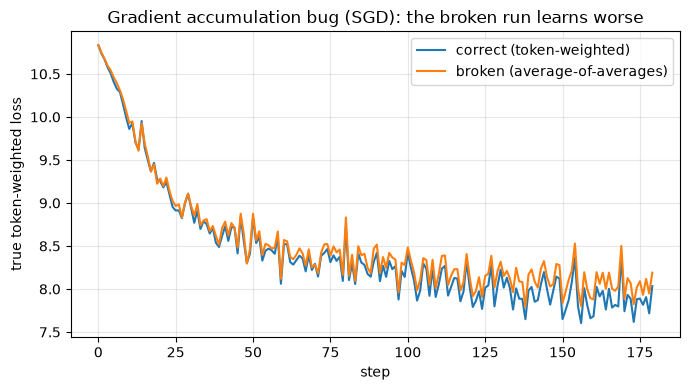

In [8]:
def train_accum(mode, steps=180, accum_lengths=(4,96,4,96), B=4, seed=0, lr=0.03):
    torch.manual_seed(seed)
    m=GPT(Config(VOCAB)).to(device)
    opt=torch.optim.SGD(m.parameters(),lr=lr,momentum=0.9)   # SGD exposes the bug (Adam would mask it)
    hist=[]
    for step in range(steps):
        micros=[get_batch(B,L) for L in accum_lengths]
        tok=[xb.shape[0]*(xb.shape[1]-1) for xb,_ in micros]; total=sum(tok)
        m.zero_grad()
        true_num=0.0   # sum of every token's loss -> true token-weighted loss for a fair comparison
        for xb,yb in micros:
            ls=F.cross_entropy(m(xb)[:,:-1].reshape(-1,VOCAB),yb[:,1:].reshape(-1),reduction="sum")
            true_num+=ls.item()
            if mode=="correct":
                (ls/total).backward()                       # token-weighted
            else:  # wrong: mean per micro, averaged equally over micro-batches
                lm=ls/(xb.shape[0]*(xb.shape[1]-1))
                (lm/len(micros)).backward()
        opt.step(); hist.append(true_num/total)
    return hist

h_correct=train_accum("correct",seed=0)
h_wrong  =train_accum("wrong",  seed=0)
print(f"final TRUE token-weighted loss  correct={h_correct[-1]:.3f}  wrong={h_wrong[-1]:.3f}  "
      f"gap={h_wrong[-1]-h_correct[-1]:+.3f}")
print(f"best  TRUE token-weighted loss  correct={min(h_correct):.3f}  wrong={min(h_wrong):.3f}")

plt.figure(figsize=(7,4))
plt.plot(h_correct,label="correct (token-weighted)")
plt.plot(h_wrong,label="broken (average-of-averages)")
plt.xlabel("step"); plt.ylabel("true token-weighted loss")
plt.title("Gradient accumulation bug (SGD): the broken run learns worse")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig("assets/accum_gap.png",dpi=110); plt.show()

**What the gap means.** Both runs report a falling loss — nothing throws, nothing looks wrong. But
the broken run optimizes a *different objective* (short micro-batches count as much as long ones), so it
converges to a **higher** true token-weighted loss. This is exactly the kind of bug the loss curve alone
will never reveal: each run's own curve looks healthy — you only see the damage by plotting the correct
and broken runs *together*.

---
## 4. Grad norm as a leading indicator

We run a real loop and log the **loss** and the **global gradient norm** every step. Grad norm and loss
live on different scales, so we compare their **relative** (%) step-to-step changes. We then find a step
where the grad norm moved sharply while the loss was ~flat — and the loss dropped in the steps *after*.
Grad norm reacts to curvature before it shows up in the loss average.

step 54: grad norm moved 517.0%  while loss moved only 0.82%  (flat)
  grad norm: 0.492 -> 3.034
  loss:      7.610 -> 7.672   then drops to 7.563 by step 57
  => the grad norm moved BEFORE the loss did.


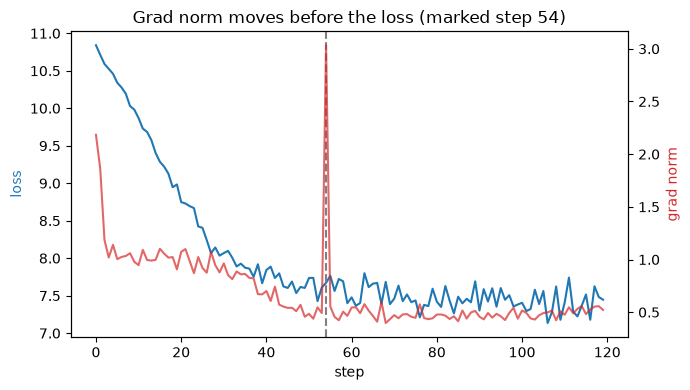

In [9]:
import numpy as np
torch.manual_seed(3)
lm_model=GPT(Config(VOCAB)).to(device)
opt=torch.optim.AdamW(lm_model.parameters(),lr=8e-4)
losses,gnorms,times,toks=[],[],[],[]
B,T=16,64
for step in range(120):
    x,y=get_batch(B,T)
    t0=time.time()
    logits=lm_model(x)
    loss=F.cross_entropy(logits[:,:-1].reshape(-1,VOCAB),y[:,1:].reshape(-1))
    opt.zero_grad(); loss.backward()
    gnorm=torch.nn.utils.clip_grad_norm_(lm_model.parameters(),1e9)  # measures, does not clip
    opt.step()
    if device=="mps": torch.mps.synchronize()
    elif device=="cuda": torch.cuda.synchronize()
    losses.append(loss.item()); gnorms.append(float(gnorm))
    times.append(time.time()-t0); toks.append(B*T)

L=np.array(losses); G=np.array(gnorms)
relL=np.abs(np.diff(L))/(np.abs(L[:-1])+1e-6)   # relative loss change at each step
relG=np.abs(np.diff(G))/(np.abs(G[:-1])+1e-6)   # relative grad-norm change
# want: big relative grad-norm move, tiny relative loss move NOW, and a loss drop over the next 3 steps
best=None
for k in range(5,len(L)-4):
    drop=L[k]-min(L[k+1:k+4])
    if drop<=0: continue
    sc=relG[k-1]*drop/(relL[k-1]+1e-3)
    if best is None or sc>best[0]: best=(sc,k,drop)
_,k,drop=best
print(f"step {k}: grad norm moved {relG[k-1]*100:5.1f}%  while loss moved only {relL[k-1]*100:4.2f}%  (flat)")
print(f"  grad norm: {G[k-1]:.3f} -> {G[k]:.3f}")
print(f"  loss:      {L[k-1]:.3f} -> {L[k]:.3f}   then drops to {min(L[k+1:k+4]):.3f} by step {k+3}")
print("  => the grad norm moved BEFORE the loss did.")

fig,ax1=plt.subplots(figsize=(7,4))
ax1.plot(losses,color="tab:blue",label="loss"); ax1.set_ylabel("loss",color="tab:blue"); ax1.set_xlabel("step")
ax2=ax1.twinx(); ax2.plot(gnorms,color="tab:red",alpha=0.7,label="grad norm"); ax2.set_ylabel("grad norm",color="tab:red")
ax1.axvline(k,ls="--",c="gray"); ax1.set_title(f"Grad norm moves before the loss (marked step {k})")
plt.tight_layout(); plt.savefig("assets/gradnorm.png",dpi=110); plt.show()

---
## 5. Model FLOPs Utilization (MFU), honestly

MFU = (FLOPs your training actually performs per second) / (the hardware's peak FLOPs).
FLOPs per token uses the nanoGPT estimate `6·N + 12·L·H·Q·T` (fwd+bwd). We measure real tokens/sec
from the loop above and divide by the device's peak.

In [10]:
N=sum(p.numel() for p in lm_model.parameters())
L_,H_,Q_,T_=cfg.n_layer,cfg.n_head,cfg.n_embd//cfg.n_head,T
flops_per_token=6*N + 12*L_*H_*Q_*T_
# use the steady-state (drop warmup) tokens/sec
import numpy as np
tps=np.array(toks[10:])/np.array(times[10:])
tokens_per_sec=float(tps.mean())
achieved=flops_per_token*tokens_per_sec

# Apple M3 Max, 40-core GPU: ~14 TFLOPS FP32 (no NVIDIA-style bf16 tensor cores; bf16 ~ fp32 here).
PEAK_FLOPS=14.2e12
mfu=achieved/PEAK_FLOPS
print(f"chip: {CHIP}  (assumed peak {PEAK_FLOPS/1e12:.1f} TFLOPS FP32 -- an ESTIMATE)")
print(f"params N            = {N:,}")
print(f"flops/token (6N+..) = {flops_per_token:,}")
print(f"tokens/sec          = {tokens_per_sec:,.0f}")
print(f"achieved FLOPS      = {achieved/1e12:.3f} TFLOP/s")
print(f"MFU                 = {mfu*100:.2f}%")
print()
print("Why we are far from 40%:")
print(" - Tiny model (128-dim, 4 layers): matmuls are too small to saturate the GPU; kernel-launch")
print("   and Python-loop overhead dominate each step.")
print(" - Small batch/seq (16x64): low arithmetic intensity -> memory-bandwidth bound, not compute bound.")
print(" - MPS eager mode: no operator fusion / graph capture (no torch.compile on MPS here); the huge")
print("   (B*T, 50257) logits+softmax is largely a bandwidth-bound op that the 6N FLOP model ignores.")
print(" - fp32 on Apple GPU: no low-precision matrix acceleration to raise the ceiling.")
print(" - To approach 40%: bigger d_model/batch, fused/compiled kernels, and lower precision.")

chip: Apple M3 Max  (assumed peak 14.2 TFLOPS FP32 -- an ESTIMATE)
params N            = 7,242,624
flops/token (6N+..) = 43,848,960
tokens/sec          = 29,093
achieved FLOPS      = 1.276 TFLOP/s
MFU                 = 8.98%

Why we are far from 40%:
 - Tiny model (128-dim, 4 layers): matmuls are too small to saturate the GPU; kernel-launch
   and Python-loop overhead dominate each step.
 - Small batch/seq (16x64): low arithmetic intensity -> memory-bandwidth bound, not compute bound.
 - MPS eager mode: no operator fusion / graph capture (no torch.compile on MPS here); the huge
   (B*T, 50257) logits+softmax is largely a bandwidth-bound op that the 6N FLOP model ignores.
 - fp32 on Apple GPU: no low-precision matrix acceleration to raise the ceiling.
 - To approach 40%: bigger d_model/batch, fused/compiled kernels, and lower precision.


---
## 6. The number 0.1 in fp32, bf16, and fp8 E4M3

`0.1` is not exactly representable in binary (it is `0.0001100110011…` repeating). Each format rounds
it differently. Layout is `sign | exponent | mantissa`; the stored value is
`(-1)^s · 1.mantissa · 2^(exp − bias)`.

By hand: `0.1 = 1.6 × 2^-4`, so the unbiased exponent is **−4** and the fraction after the leading 1 is
**0.6 = 0.100110011…₂**.

| format | sign | exp bits (bias) | mantissa bits | exp field |
|--------|------|-----------------|---------------|-----------|
| fp32   | 1 | 8 (127) | 23 | 127−4 = 123 = `01111011` |
| bf16   | 1 | 8 (127) | 7  | `01111011` |
| fp8 E4M3 | 1 | 4 (7) | 3 | 7−4 = 3 = `0011` |


In [11]:
def fp32_bits(f):
    b=struct.unpack(">I",struct.pack(">f",f))[0]; s=f"{b:032b}"; return s[0],s[1:9],s[9:]
s,e,m=fp32_bits(0.1)
back32=struct.unpack(">f",struct.pack(">f",0.1))[0]
print(f"fp32   0.1 = {s} {e} {m}")
print(f"           = sign {s}, exp {int(e,2)}-127={int(e,2)-127}, 23-bit mantissa -> {back32!r}")

bf=torch.tensor(0.1,dtype=torch.bfloat16); bb=bf.view(torch.int16).item()&0xFFFF; bs=f"{bb:016b}"
print(f"bf16   0.1 = {bs[0]} {bs[1:9]} {bs[9:]}")
print(f"           = same exponent as fp32, mantissa truncated 23->7 bits -> {float(bf)!r}")

# fp8 E4M3 by hand (bias 7, 3 mantissa bits, round-to-nearest)
x=0.1; e=math.floor(math.log2(x)); frac=x/2**e-1; q=round(frac*8)
if q==8: q=0; e+=1
be=e+7; val=(1+q/8)*2**(be-7)
print(f"fp8    0.1 = 0 {be:04b} {q:03b}")
print(f"           = exp {be}-7={be-7}, mantissa {q}/8={q/8} -> {val}")
try:
    t8=torch.tensor(0.1,dtype=torch.float8_e4m3fn); print(f"           torch float8_e4m3fn confirms -> {float(t8)}")
except Exception as ex: print("           (torch fp8 check skipped:",type(ex).__name__,")")

print("\nRounding error vs true 0.1:")
print(f"  fp32 : {abs(back32-0.1):.2e}")
print(f"  bf16 : {abs(float(bf)-0.1):.2e}")
print(f"  fp8  : {abs(val-0.1):.2e}")

fp32   0.1 = 0 01111011 10011001100110011001101
           = sign 0, exp 123-127=-4, 23-bit mantissa -> 0.10000000149011612
bf16   0.1 = 0 01111011 1001101
           = same exponent as fp32, mantissa truncated 23->7 bits -> 0.10009765625
fp8    0.1 = 0 0011 101
           = exp 3-7=-4, mantissa 5/8=0.625 -> 0.1015625
           torch float8_e4m3fn confirms -> 0.1015625

Rounding error vs true 0.1:
  fp32 : 1.49e-09
  bf16 : 9.77e-05
  fp8  : 1.56e-03


### Which one would I train in?

**bf16** — for the weights/activations in the hot path, with fp32 master weights and fp32
accumulation (standard mixed precision).

- **bf16 over fp32:** bf16 keeps fp32's *full 8-bit exponent* (same dynamic range, ~1e-38…3e38), so
  it does not overflow/underflow where training lives; it only sacrifices mantissa precision, which SGD
  tolerates well. Half the memory and bandwidth of fp32 — and bandwidth is what bounds us (see MFU).
- **not fp8 E4M3:** only 3 mantissa bits and a 4-bit exponent (max ≈ 448). Its rounding error on 0.1 is
  ~100× bf16's, and its range is far too small to hold gradients/optimizer state without per-tensor
  scaling. fp8 is useful only for specific scaled matmuls, never as the default training type.
- **not fp32:** correct but wasteful — 2× the memory/bandwidth for precision the optimizer doesn't need.

So: **train in bf16, accumulate and keep master weights in fp32.**


---
# Write-up

**1. Shapes.** Every tensor in the step is printed with its dimensions named; every gradient tensor
has exactly the shape of its parameter — the check that catches silent broadcasting bugs.

**2. Gradient check.** `backward()` vs central finite difference on one weight agree to **~9 decimals**
(diff ~1e-10 in fp64). Autograd is telling the truth for that weight.

**3. Broken accumulation.** Average-of-averages vs token-weighted, with uneven micro-batches: the
losses differ and — more importantly — the per-step **gradients point in different directions**
(cosine < 1). Under **SGD** the broken run converges to a visibly higher true loss. (Under Adam the gap
nearly vanishes — Adam's per-parameter normalization masks the reweighting — which is *why* the honest
way to expose this bug is with SGD.) Either way the bug is completely silent.

**4. Grad norm leads.** Logging the grad norm every step reveals a step where it moved sharply while
the loss was flat, with the loss moving afterward — grad norm is a leading indicator of training
dynamics that the loss average lags.

**5. MFU.** Reported honestly for the Apple M3 Max. It is low because the model and batch are tiny
(memory-bandwidth bound, kernel-launch/Python overhead, MPS eager mode, fp32). The distance to 40% is
bigger matmuls, fused/compiled kernels, and lower precision.

**6. 0.1 in fp32/bf16/fp8.** Bit patterns derived by hand and confirmed in code. I would train in
**bf16** (fp32 master weights + accumulation): it preserves fp32's dynamic range while halving
bandwidth; fp8 E4M3 lacks the precision and range to be a default training type.

**The theme.** Every serious training bug here was silent. The loss curve never raised its hand — the
prints and the by-hand checks did.
